# EfficientNet implementation

# 🔽Imports

In [2]:
import random
import math
from kaggle_secrets import UserSecretsClient
import itertools
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from timm import create_model
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from google.colab import drive
import shutil
import os
import json
import torch.nn.functional as F
from torchvision import transforms
import cv2
import pandas as pd

#W&B
%pip install wandb -q
import wandb
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("wandb")
wandb.login(key=secret_value_0)

Note: you may need to restart the kernel to use updated packages.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: leopit14 (francesco-pimpinelli-sapienza-universit-di-roma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 🐈‍⬛GitHub 

In [3]:
!git clone https://github.com/Pimpi7/CV_project

Cloning into 'CV_project'...
remote: Enumerating objects: 10027, done.
remote: Total 10027 (delta 0), reused 0 (delta 0), pack-reused 10027 (from 3)
Receiving objects: 100% (10027/10027), 1.51 GiB | 56.66 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (9992/9992), done.


# 🌐Globals

## 🔤Paths

In [4]:
DATASET_PATHS = {
    'train': 'CV_project/dataset/samples/train',
    'test': 'CV_project/dataset/samples/test',
    'eval': 'CV_project/dataset/samples/validation'
}
FINETUNED_BASE_MODEL_PATH = 'CV_project/models/best_model_bs32_lr0.001_e30_PIM_False.pth'
FINETUNED_PIM_MODEL_PATH = 'CV_project/models/best_model_bs16_lr0.001_e30_PIM_True.pth'

## 🔁Repeatability


In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def ensure_repeatability():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## 🔢Hyperparameters

### 🕹️Control Room

In [46]:
GRID_SEARCH = False          # flag true if you want to perform a grid search, false if you only want to train
LOAD_FINETUNED = True        # flag true if you want to load our best fine-tuned model (modify below to choose if with PIM or not)
PLUG_PIM = False             # flag true if you want to plug PIM, false otherwise
ADV_ATTACK_TYPE = 'MI-FGSM'      # other options: 'FGSM', 'PGD', 'MI-FGSM', 'None'

### 🎛️Others

In [7]:
# For the grid search
BATCH_SIZES = [16, 32, 64]
LEARNING_RATES = [1e-5, 1e-4, 1e-3]
NUM_EPOCHS = [30]

# Personalized configuration
BATCH_SIZE = BATCH_SIZES[1]
LEARNING_RATE = LEARNING_RATES[2]
EPOCHS = 30

NUM_CLASSES = 2  
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# 🔧Utils


## 🔌Perturbation Injection Module (PIM)

In [8]:
class PerturbationInjectionModule(nn.Module):
    
    def __init__(self, r=0.1, alpha=1.0):
        
        """
          r: perturbation intensity
          alpha: balance between empiric loss and regularized loss
        """
        super().__init__()
        self.r = r
        self.alpha = alpha
        self.mu = None
        self.sigma = None
        self.delta_mu = None
        self.delta_sigma = None
        self.first_fwpass_done = False #First or second passage
    
    
    def normalize(self, features):
    
        self.mu = features.mean(dim=[2, 3], keepdim=True).detach()
        self.sigma = features.std(dim=[2, 3], keepdim=True, correction=0).detach() + 1e-5
    
        return (features - self.mu)/self.sigma
    
    
    def perturb(self, features, grad_mu, grad_sigma):
    
        # gradients concatenation
        gradients = torch.cat([grad_mu.view(-1), grad_sigma.view(-1)])
    
        # gradient normalizzation
        norm = torch.norm(gradients, p=2)
        unit_vector = gradients / (norm + 1e-10)
        delta = self.r * unit_vector
    
        # get delta_mu and delta_sigma
        split_index = grad_mu.numel()
        self.delta_mu = delta[:split_index].view_as(grad_mu)
        self.delta_sigma = delta[split_index:].view_as(grad_sigma)
    
        # compute mu and sigma perturbed
        mu_perturbed = self.mu + self.delta_mu
        sigma_perturbed = self.sigma + self.delta_sigma
    
        # projection in perturbed space
        return features * sigma_perturbed + mu_perturbed
    
    
    def forward(self, features, loss=None, target=None):
    
        # inference
        if not self.training or loss is None:
            return features
        
        # first fw_pass is normal
        if not self.first_fwpass_done:
        
            features_norm = self.normalize(features)
            features_norm.requires_grad_(True)
            self.first_fwpass_done = True
        
            return features_norm
        
        # do a proper fw_pass
        else:
            features_norm = (features - self.mu) / self.sigma
            features_norm.requires_grad_(True)
            features_norm.retain_grad()
        
            # second fw with a backpass for getting mu and sigma
            output = features_norm.clone()
            logits = loss(output, target)
            logits.backward(retain_graph=True)
            
            grad_mu = torch.autograd.grad(logits, self.mu, retain_graph=True, allow_unused = True)[0]
            grad_sigma = torch.autograd.grad(logits, self.sigma, retain_graph=True, allow_unused=True)[0]
        
            if grad_mu is None or grad_sigma is None:
                raise RuntimeError("Gradient not propagated to mu or sigma.")
            
            perturbed_feats = self.perturb(features_norm, grad_mu, grad_sigma)
            return perturbed_feats
    
    def reset(self):
        # resetta tutto per il prossimo batch
        self.mu = None
        self.sigma = None
        self.delta_mu = None
        self.delta_sigma = None
        self.first_fwpass_done = False

## ✅Evaluation functions

In [9]:
#Evaluation function used both for finding best model and evaluating in deep the last one
def evaluate(model, loader, simple=True):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    if simple:
        acc = np.mean(np.array(all_preds) == np.array(all_labels))
        return acc
    else:
        acc = np.mean(np.array(all_preds) == np.array(all_labels))
        f1 = f1_score(all_labels, all_preds, average='weighted')
        report = classification_report(all_labels, all_preds, target_names=['Real', 'Fake'])
        conf_matrix = confusion_matrix(all_labels, all_preds)
        return acc, f1, report, conf_matrix, all_labels, all_preds

###  ☑️Adversarial evaluation

In [10]:
def run_adversarial_evaluation(model):
    """
    Main function to run all the adversarial attacks' evaluation
    """
    
    wandb.init(
        entity="francesco-pimpinelli-sapienza-universit-di-roma",
        project="EfficientNet-Deepfake-Detection",
        job_type="adversarial_evaluation",
        name="Adversarial_Robustness_Comprehensive",
        config={
            "model": "EfficientNetV2_rw_s",
            "dataset": "DFFD distilled",
            "attack_types": ["FGSM", "PGD", "MI-FGSM"],
            "epsilons": [0.01, 0.05, 0.1],
            "test_samples": "full_test_set"  # or however many you're using
        }
    )
    
    # Create tables for W&B logging
    attack_results_table = wandb.Table(columns=[
        "Attack", "Epsilon", "Clean_Acc", "Adv_Acc", "Success_Rate", 
        "L2_Distance", "Linf_Distance", "Conf_Drop"
    ])
    
    # Initialize attack class
    attacks = AdversarialAttacks(model, DEVICE)
    
    # Create test dataloader
    config = resolve_data_config({}, model=model)
    transform = create_transform(**config)
    test_dataset = datasets.ImageFolder(DATASET_PATHS['test'], transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True, num_workers=2)
    
    # Test different attack methods
    epsilons = [0.01, 0.05, 0.1]
    
    print("="*60)
    print("ADVERSARIAL ROBUSTNESS EVALUATION")
    print("="*60)
    
    results = {}
    
    # FGSM Attack
    print("\n1. Fast Gradient Sign Method (FGSM)")
    print("-" * 40)
    for eps in epsilons:
        result = attacks.evaluate_robustness(test_loader, 'fgsm', epsilon=eps)
        results[f'fgsm_eps_{eps}'] = result
        
        # Log to W&B immediately
        wandb.log({
            f"fgsm_eps_{eps}_clean_accuracy": result['clean_accuracy'],
            f"fgsm_eps_{eps}_adversarial_accuracy": result['adversarial_accuracy'],
            f"fgsm_eps_{eps}_attack_success_rate": result['attack_success_rate'],
            f"fgsm_eps_{eps}_avg_l2_distance": result['avg_l2_distance'],
            f"fgsm_eps_{eps}_avg_linf_distance": result['avg_linf_distance'],
            f"fgsm_eps_{eps}_avg_confidence_drop": result['avg_confidence_drop']
        })
        
        # Add to table
        attack_results_table.add_data(
            "FGSM", eps, result['clean_accuracy'], result['adversarial_accuracy'],
            result['attack_success_rate'], result['avg_l2_distance'],
            result['avg_linf_distance'], result['avg_confidence_drop']
        )
    
    # PGD Attack
    print("\n2. Projected Gradient Descent (PGD)")
    print("-" * 40)
    for eps in epsilons:
        result = attacks.evaluate_robustness(test_loader, 'pgd', epsilon=eps, alpha=eps/4, num_iter=10)
        results[f'pgd_eps_{eps}'] = result
        
        # Log to W&B immediately
        wandb.log({
            f"pgd_eps_{eps}_clean_accuracy": result['clean_accuracy'],
            f"pgd_eps_{eps}_adversarial_accuracy": result['adversarial_accuracy'],
            f"pgd_eps_{eps}_attack_success_rate": result['attack_success_rate'],
            f"pgd_eps_{eps}_avg_l2_distance": result['avg_l2_distance'],
            f"pgd_eps_{eps}_avg_linf_distance": result['avg_linf_distance'],
            f"pgd_eps_{eps}_avg_confidence_drop": result['avg_confidence_drop']
        })
        
        # Add to table
        attack_results_table.add_data(
            "PGD", eps, result['clean_accuracy'], result['adversarial_accuracy'],
            result['attack_success_rate'], result['avg_l2_distance'],
            result['avg_linf_distance'], result['avg_confidence_drop']
        )
    
    # C&W Attack (only one test due to computational cost)
    print("\n3. Momentum Iterative FGSM (MI-FGSM)")
    print("-" * 40)
    for eps in epsilons:
        result = attacks.evaluate_robustness(test_loader, 'mi-fgsm', epsilon=eps, alpha=eps/4, num_iter=10)
        results[f'mi_fgsm_eps_{eps}'] = result
        
        # Log to W&B
        wandb.log({
            f"mi_fgsm_eps_{eps}_clean_accuracy": result['clean_accuracy'],
            f"mi_fgsm_eps_{eps}_adversarial_accuracy": result['adversarial_accuracy'],
            f"mi_fgsm_eps_{eps}_attack_success_rate": result['attack_success_rate'],
            f"mi_fgsm_eps_{eps}_avg_l2_distance": result['avg_l2_distance'],
            f"mi_fgsm_eps_{eps}_avg_linf_distance": result['avg_linf_distance'],
            f"mi_fgsm_eps_{eps}_avg_confidence_drop": result['avg_confidence_drop']
        })
        
        # Add to table
        attack_results_table.add_data(
            "MI-FGSM", eps, result['clean_accuracy'], result['adversarial_accuracy'],
            result['attack_success_rate'], result['avg_l2_distance'],
            result['avg_linf_distance'], result['avg_confidence_drop']
        )
    
    # Log the complete results table
    wandb.log({"adversarial_results_table": attack_results_table})
    
    # Create and log robustness plots
    create_robustness_plots(results, epsilons)
    
    # Visualize some examples
    print("\n4. Visualization Examples")
    print("-" * 40)
    
    # Get a sample from test set
    data_iter = iter(test_loader)
    sample_data, sample_target = next(data_iter)
    sample_data, sample_target = sample_data.to(DEVICE), sample_target.to(DEVICE)
    
    print("FGSM Attack Visualization:")
    fgsm_result = attacks.visualize_attack(sample_data, sample_target, 'fgsm', epsilon=0.01)
    
    print("PGD Attack Visualization:")
    pgd_result = attacks.visualize_attack(sample_data, sample_target, 'pgd', epsilon=0.01)
    
    # Log example attack results
    wandb.log({
        "example_fgsm_success": fgsm_result['attack_successful'],
        "example_fgsm_conf_drop": fgsm_result['confidence_drop'],
        "example_pgd_success": pgd_result['attack_successful'],
        "example_pgd_conf_drop": pgd_result['confidence_drop']
    })
    
    # Log final summary metrics
    wandb.log({
        "summary_worst_fgsm_accuracy": min([results[f'fgsm_eps_{eps}']['adversarial_accuracy'] for eps in epsilons]),
        "summary_worst_pgd_accuracy": min([results[f'pgd_eps_{eps}']['adversarial_accuracy'] for eps in epsilons]),
        "summary_avg_conf_drop_fgsm": np.mean([results[f'fgsm_eps_{eps}']['avg_confidence_drop'] for eps in epsilons]),
        "summary_avg_conf_drop_pgd": np.mean([results[f'pgd_eps_{eps}']['avg_confidence_drop'] for eps in epsilons])
    })
    
    wandb.finish()
    return results

def create_robustness_plots(results, epsilons):
    """Create and log robustness plots to W&B"""
    
    # Extract data for plotting
    fgsm_accs = [results[f'fgsm_eps_{eps}']['adversarial_accuracy'] for eps in epsilons]
    pgd_accs = [results[f'pgd_eps_{eps}']['adversarial_accuracy'] for eps in epsilons]
    fgsm_conf_drops = [results[f'fgsm_eps_{eps}']['avg_confidence_drop'] for eps in epsilons]
    pgd_conf_drops = [results[f'pgd_eps_{eps}']['avg_confidence_drop'] for eps in epsilons]
    
    # Accuracy vs Epsilon plot
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epsilons, fgsm_accs, 'o-', label='FGSM', linewidth=2, markersize=8)
    plt.plot(epsilons, pgd_accs, 's-', label='PGD', linewidth=2, markersize=8)
    plt.xlabel('Epsilon (Attack Strength)')
    plt.ylabel('Adversarial Accuracy (%)')
    plt.title('Model Robustness vs Attack Strength')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Confidence Drop vs Epsilon plot
    plt.subplot(1, 2, 2)
    plt.plot(epsilons, fgsm_conf_drops, 'o-', label='FGSM', linewidth=2, markersize=8)
    plt.plot(epsilons, pgd_conf_drops, 's-', label='PGD', linewidth=2, markersize=8)
    plt.xlabel('Epsilon (Attack Strength)')
    plt.ylabel('Average Confidence Drop')
    plt.title('Confidence Drop vs Attack Strength')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Log to W&B
    wandb.log({"robustness_plots": wandb.Image(plt)})
    plt.show()

## ⚙️Train function

In [11]:
def train_model(model, batch_size, learning_rate, num_epochs, patience=5):
    """Train model with specific hyperparameters and early stopping"""
    
    if GRID_SEARCH:
        ensure_repeatability()
 
        # Create model
        model = create_model('efficientnetv2_rw_s', pretrained=True, num_classes=NUM_CLASSES)
        
        #for the model with PIM
        if PLUG_PIM:
            pim = PerturbationInjectionModule(r=0.1, alpha=1.0)
            model = EfficientNetWithPIM(model, pim)

    config = resolve_data_config({}, model=model)
    transform = create_transform(**config)

    # Dataset e loader
    train_dataset = datasets.ImageFolder(DATASET_PATHS['train'], transform=transform)
    eval_dataset = datasets.ImageFolder(DATASET_PATHS['eval'], transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    model = model.to(DEVICE)
    class_counts = np.bincount([label for _, label in train_dataset.imgs])
    class_weights = torch.tensor(1. / class_counts, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

    # Run W&B
    run_name = f'bs:{batch_size}_lr:{learning_rate}_e:{num_epochs}_PIM:{PLUG_PIM}'
    
    if GRID_SEARCH:
        group_name = f'GridSearch_PIM:{PLUG_PIM}'
    else:
        group_name = f'Trainings_PIM:{PLUG_PIM}'
        
    run = wandb.init(
        entity="francesco-pimpinelli-sapienza-universit-di-roma",
        project="EfficientNet-Deepfake-Detection",
        job_type="training",
        config={
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "epochs": num_epochs,
            "architecture": "EfficientNetV2_rw_s",
            "dataset": "DFFD distilled"
        },
        group = group_name,
        name=run_name,
        reinit=True
    )

    best_val_acc = 0.0
    best_epoch = 0
    epochs_no_improve = 0
    model_path = f'CV_project/models/best_model_bs{batch_size}_lr{learning_rate}_e{num_epochs}_PIM:{PLUG_PIM}.pth'

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            # for the model with PIM
            if PLUG_PIM:
              model.pim.reset()

              # First pass
              outputs1 = model(inputs, labels=labels, loss_fn=criterion, use_pim=False)
              loss1 = criterion(outputs1, labels)

              # Second pass (with PIM)
              outputs2 = model(inputs, labels=labels, loss_fn=criterion, use_pim=True)
              loss2 = criterion(outputs2, labels)

              #combined loss
              loss = (1- model.pim.alpha) * loss1 + model.pim.alpha * loss2
                
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        val_acc = evaluate(model, eval_loader, simple=True)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_path)
        else:
            epochs_no_improve += 1

        wandb.log({
            "training_loss": epoch_loss,
            "validation_accuracy": val_acc,
            "epoch": epoch
        })

        print(f'[{run_name}] Epoch {epoch+1}: Loss={epoch_loss:.4f}, ValAcc={val_acc:.4f}')

        if epochs_no_improve >= patience:
            print(f"[{run_name}] Early stopping at epoch {epoch+1}")
            break

    wandb.log({"best_validation_accuracy": best_val_acc, "best_epoch": best_epoch})
    wandb.finish()

    return best_val_acc, model_path

## 🔎GridSearch

In [12]:
def grid_search(model):
    grid_search_results = []
    best_overall_acc = 0.0
    best_overall_params = None
    
    print("Starting Grid Search...")
    print("="*60)
    param_combinations = list(itertools.product(BATCH_SIZES, LEARNING_RATES, NUM_EPOCHS))
    print(f"Total combinations to test: {len(param_combinations)}")
    
    for i, (batch_size, learning_rate, num_epochs) in enumerate(param_combinations):
        print(f"\nCombination {i+1}/{len(param_combinations)}")
        print(f"Batch Size: {batch_size}, Learning Rate: {learning_rate}, Epochs: {num_epochs}")
        print("-" * 40)
        
        try:
            val_acc, model_path = train_model(model, batch_size, learning_rate, num_epochs)
            
            # Store results
            result = {
                'batch_size': batch_size,
                'learning_rate': learning_rate,
                'num_epochs': num_epochs,
                'validation_accuracy': val_acc,
                'model_path': model_path
            }
            grid_search_results.append(result)
            
            # Update best overall result
            if val_acc > best_overall_acc:
                best_overall_acc = val_acc
                best_overall_params = (batch_size, learning_rate, num_epochs)
            
            print(f"Completed: Val Acc = {val_acc:.4f}")
            
        except Exception as e:
            print(f"Failed: {str(e)}")
            continue
    
    # RESULTS SUMMARY
    print("\n" + "="*60)
    print("GRID SEARCH RESULTS")
    print("="*60)
    
    # Sort results by validation accuracy
    grid_search_results.sort(key=lambda x: x['validation_accuracy'], reverse=True)
    
    print("\nTop 5 combinations:")
    for i, result in enumerate(grid_search_results[:5]):
        print(f"{i+1}. BS:{result['batch_size']}, LR:{result['learning_rate']}, E:{result['num_epochs']} "
              f"-> Val Acc: {result['validation_accuracy']:.4f}")
    
    print(f"\nBest combination:")
    print(f"Batch Size: {best_overall_params[0]}")
    print(f"Learning Rate: {best_overall_params[1]}")
    print(f"Epochs: {best_overall_params[2]}")
    print(f"Best Validation Accuracy: {best_overall_acc:.4f}")
    
    # Save results to JSON
    results_path = 'CV_project/models/grid_search_results.json'
    with open(results_path, 'w') as f:
        json.dump(grid_search_results, f, indent=2)
    print(f"\nResults saved to: {results_path}") 

    # Return best model
    best_model = grid_search_results[0]
    return best_model

## ⚔️Adversarial attacks

The **AdversarialAttacks** class implements the following algorithms:

* **FGSM** ("Fast Gradient Sign Method") - Adds noise to the image in a single step. 
  
* **PGD** ("Projected Gradient Descent") -  Like FGSM but repeats the process multiple times to be more effective
  
* **MI-FGSM** ("Momentum Iterative FGSM") - Like PGD but with "momentum"


Other than that, a function for evaluation and one for visualization purposes are also implemented.


**Evaluation Metrics:**

* Clean accuracy (on original images)
* Adversarial accuracy (on attacked images)
* Attack success rate
* Average L2 perturbation distance
* Average Linf perturbation distance
* Average confidence drop

In [13]:
class AdversarialAttacks:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.model.eval()
    
    def fgsm_attack(self, image, target, epsilon=0.01):
        """
        Fast Gradient Sign Method (FGSM) Attack
        
        Args:
            image: Input image tensor
            target: True label
            epsilon: Attack strength
        """
        image.requires_grad = True
        
        # Forward pass
        output = self.model(image)
        loss = F.cross_entropy(output, target)
        
        # Backward pass
        self.model.zero_grad()
        loss.backward()
        
        # Generate adversarial example
        data_grad = image.grad.data
        sign_data_grad = data_grad.sign()
        perturbed_image = image + epsilon * sign_data_grad
        perturbed_image = torch.clamp(perturbed_image, 0, 1)
        
        return perturbed_image.detach()
    
    def pgd_attack(self, image, target, epsilon=0.01, alpha=0.01, num_iter=10):
        """
        Projected Gradient Descent (PGD) Attack
        
        Args:
            image: Input image tensor
            target: True label
            epsilon: Maximum perturbation
            alpha: Step size
            num_iter: Number of iterations
        """
        # Random initialization
        delta = torch.zeros_like(image).uniform_(-epsilon, epsilon).to(self.device)
        
        for i in range(num_iter):
            delta_var = delta.clone().detach().requires_grad_(True)
            
            # Forward pass
            perturbed_image = image + delta_var
            output = self.model(perturbed_image)
            loss = F.cross_entropy(output, target)
            
            # Backward pass
            loss.backward()
            
            # Update delta (in the direction of the gradient to keep it more effective)
            if delta_var.grad is not None:
                grad = delta_var.grad.detach()
                # Update delta and project
                delta = delta + alpha * grad.sign()
                delta = torch.clamp(delta, -epsilon, epsilon)
                delta = torch.clamp(image + delta, 0, 1) - image
            
        return (image + delta).detach()
    
    def mi_fgsm_attack(self, image, target, epsilon=0.01, alpha=0.01, num_iter=10, decay=1.0):
        """
        Momentum Iterative FGSM Attack
        """
        delta = torch.zeros_like(image).to(self.device)
        momentum = torch.zeros_like(image).to(self.device)
        
        for i in range(num_iter):
            delta.requires_grad = True
            
            adv_image = image + delta
            output = self.model(adv_image)
            loss = F.cross_entropy(output, target)
            
            loss.backward()
            
            if delta.grad is not None:
                grad = delta.grad.detach()
                
                # Momentum update
                momentum = decay * momentum + grad / torch.norm(grad, p=1)
                
                delta = delta + alpha * momentum.sign()
                delta = torch.clamp(delta, -epsilon, epsilon)
                delta = torch.clamp(image + delta, 0, 1) - image
                delta = delta.detach()
        
        return (image + delta).detach()
    
    def evaluate_robustness(self, dataloader, attack_type='fgsm', epsilon=0.01, **kwargs):
        """
        Evaluate model robustness against adversarial attacks
        
        Args:
            dataloader: Test data loader
            attack_type: Type of attack ('fgsm', 'pgd', 'mi-fgsm')
            epsilon: Attack strength
        """
        self.model.eval()
        
        correct_clean = 0
        correct_adv = 0
        total = 0
        
        attack_success_rate = 0
        l2_distances = []
        linf_distances = []
        confidence_drops = []
        
        for batch_idx, (data, target) in enumerate(dataloader):
            # if batch_idx >= 50:  # Limit test set for debugging / quicker demonstration
            #    break
                
            data, target = data.to(self.device), target.to(self.device)
            
            # Clean prediction
            with torch.no_grad():
                clean_output = self.model(data)
                clean_pred = clean_output.argmax(dim=1)
                clean_conf = F.softmax(clean_output, dim=1).max(dim=1)[0]
                correct_clean += (clean_pred == target).sum().item()
            
            # Generate adversarial examples
            if attack_type == 'fgsm':
                adv_data = self.fgsm_attack(data, target, epsilon)
            elif attack_type == 'pgd':
                adv_data = self.pgd_attack(data, target, epsilon, **kwargs)
            elif attack_type == 'mi-fgsm':
                adv_data = self.mi_fgsm_attack(data, target, epsilon, **kwargs)
            
            # Adversarial prediction
            with torch.no_grad():
                adv_output = self.model(adv_data)
                adv_pred = adv_output.argmax(dim=1)
                adv_conf = F.softmax(adv_output, dim=1).max(dim=1)[0]
                correct_adv += (adv_pred == target).sum().item()
            
            # Calculate attack success rate and L2 distance
            attack_success = (clean_pred == target) & (adv_pred != target)
            attack_success_rate += attack_success.sum().item()

            # L2 distance
            l2_dist = torch.norm((adv_data - data).view(data.size(0), -1), dim=1)
            l2_distances.extend(l2_dist.detach().cpu().numpy())

            # Linf distance
            linf_dist = torch.max(torch.abs(adv_data - data).view(data.size(0), -1), dim=1)[0]
            linf_distances.extend(linf_dist.detach().cpu().numpy())

            # Confidence drop
            conf_drop = clean_conf - adv_conf
            confidence_drops.extend(conf_drop.detach().cpu().numpy())
            
            
            total += target.size(0)
        
        clean_acc = 100. * correct_clean / total
        adv_acc = 100. * correct_adv / total
        attack_success_rate = 100. * attack_success_rate / total
        avg_l2_dist = np.mean(l2_distances)
        avg_linf_dist = np.mean(linf_distances)
        avg_conf_drop = np.mean(confidence_drops)
        
        print(f'\n{attack_type.upper()} Attack Results (epsilon={epsilon}):')
        print(f'Clean Accuracy: {clean_acc:.2f}%')
        print(f'Adversarial Accuracy: {adv_acc:.2f}%')
        print(f'Attack Success Rate: {attack_success_rate:.2f}%')
        print(f'Average L2 Distance: {avg_l2_dist:.4f}')
        print(f'Average L∞ Distance: {avg_linf_dist:.4f}')
        print(f'Average Confidence Drop: {avg_conf_drop:.4f}')
        
        return {
            'clean_accuracy': clean_acc,
            'adversarial_accuracy': adv_acc,
            'attack_success_rate': attack_success_rate,
            'avg_l2_distance': avg_l2_dist,
            'avg_linf_distance': avg_linf_dist,
            'avg_confidence_drop': avg_conf_drop
        }
            
    def visualize_attack(self, image, target, attack_type='fgsm', epsilon=0.01):
        """
        Visualize original vs adversarial example with enhanced metrics
        """
        if attack_type == 'fgsm':
            adv_image = self.fgsm_attack(image, target, epsilon)
        elif attack_type == 'pgd':
            adv_image = self.pgd_attack(image, target, epsilon)
        elif attack_type == 'mi-fgsm':
            adv_image = self.mi_fgsm_attack(image, target, epsilon)
        
        # Predictions
        with torch.no_grad():
            clean_output = self.model(image)
            adv_output = self.model(adv_image)
            
            clean_pred = clean_output.argmax(dim=1).item()
            adv_pred = adv_output.argmax(dim=1).item()
            
            clean_conf = F.softmax(clean_output, dim=1).max().item()
            adv_conf = F.softmax(adv_output, dim=1).max().item()
        
        # Calculate perturbation metrics
        perturbation = adv_image - image
        l2_dist = torch.norm(perturbation).item()
        linf_dist = torch.max(torch.abs(perturbation)).item()  # L∞ distance
        conf_drop = clean_conf - adv_conf  # Confidence drop
        
        # Convert to numpy for visualization
        def tensor_to_numpy(tensor):
            tensor = tensor.squeeze().detach().cpu()
            if tensor.shape[0] == 3:  # RGB
                tensor = tensor.permute(1, 2, 0)
            return tensor.numpy()
        
        original = tensor_to_numpy(image)
        adversarial = tensor_to_numpy(adv_image)
        noise = tensor_to_numpy(perturbation)
        
        # Normalize noise for visualization
        noise = (noise - noise.min()) / (noise.max() - noise.min())
        
        # Enhanced Plot
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Original image
        axes[0].imshow(original)
        class_name = "Real" if clean_pred == 0 else "Fake"
        axes[0].set_title(f'Original\nPred: {class_name}\nConf: {clean_conf:.3f}', fontsize=12)
        axes[0].axis('off')
        
        # Perturbation with enhanced metrics
        axes[1].imshow(noise, cmap='hot')
        axes[1].set_title(f'Perturbation\nL2: {l2_dist:.4f}\nL∞: {linf_dist:.4f}', fontsize=12)
        axes[1].axis('off')
        
        # Adversarial image
        axes[2].imshow(adversarial)
        adv_class_name = "Real" if adv_pred == 0 else "Fake"
        axes[2].set_title(f'Adversarial\nPred: {adv_class_name}\nConf: {adv_conf:.3f}\nDrop: {conf_drop:.3f}', fontsize=12)
        axes[2].axis('off')
        
        # Add overall attack info
        attack_success = "✓ SUCCESS" if clean_pred != adv_pred else "✗ FAILED"
        attack_color = "red" if clean_pred != adv_pred else "green"
        
        fig.suptitle(f'{attack_type.upper()} Attack (ε={epsilon}) - {attack_success}', 
                     fontsize=16, color=attack_color, weight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed summary
        print(f"\n Attack Summary:")
        print(f"   Original: {class_name} (confidence: {clean_conf:.3f})")
        print(f"   Adversarial: {adv_class_name} (confidence: {adv_conf:.3f})")
        print(f"   Confidence Drop: {conf_drop:.3f}")
        print(f"   L2 Distance: {l2_dist:.4f}")
        print(f"   L∞ Distance: {linf_dist:.4f}")
        print(f"   Attack Success: {'Yes' if clean_pred != adv_pred else 'No'}")
        
        return {
            'original_pred': clean_pred,
            'adversarial_pred': adv_pred,
            'l2_distance': l2_dist,
            'linf_distance': linf_dist,
            'confidence_drop': conf_drop,
            'attack_successful': clean_pred != adv_pred,
            'original_confidence': clean_conf,
            'adversarial_confidence': adv_conf
        }

# 🔣Data

In [40]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Caricamento dei dataset
train_dataset = datasets.ImageFolder(DATASET_PATHS['train'], transform=transform)
test_dataset = datasets.ImageFolder(DATASET_PATHS['test'], transform=transform)
eval_dataset = datasets.ImageFolder(DATASET_PATHS['eval'], transform=transform)

# Creazione dei DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

total_samples = len(train_dataset) + len(test_dataset) + len(eval_dataset)
print(f"Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}, Evaluation samples: {len(eval_dataset)}")

#Overwiev
print("\nOverview:")
print(f"Total number of samples: {total_samples}")
print(f"Split:")
print(f"Training set: {round((len(train_dataset)*100)/total_samples)}%")
print(f"Test set: {round((len(test_dataset)*100)/total_samples)}%")
print(f"Validation set: {round((len(eval_dataset)*100)/total_samples)}%")

Training samples: 6998, Test samples: 1494, Evaluation samples: 1494

Overview:
Total number of samples: 9986
Split:
Training set: 70%
Test set: 15%
Validation set: 15%


# 🖥️Network

## 🥅EfficientNetV2 small (base)

In [15]:
# Implement the efficient net rewritten, with pretrained weights on ImageNet
model = create_model('efficientnetv2_rw_s', pretrained=True, num_classes=NUM_CLASSES)

model.safetensors:   0%|          | 0.00/96.5M [00:00<?, ?B/s]

## 🆙EfficientNetV2 small (PIM)

In [16]:
class EfficientNetWithPIM(nn.Module):
    def __init__(self, base_model, pim, shallow_index=2):
        super().__init__()
        self.pim = pim
        self.shallow_index = shallow_index

        # Salva i moduli base
        self.conv_stem = base_model.conv_stem
        self.bn1 = base_model.bn1
        self.blocks = base_model.blocks
        self.conv_head = base_model.conv_head
        self.bn2 = base_model.bn2
        self.global_pool = base_model.global_pool
        self.classifier = base_model.classifier

    def forward(self, x, labels=None, loss_fn=None, use_pim=False):
        x = self.conv_stem(x)
        x = self.bn1(x)

        for i, block in enumerate(self.blocks):
            x = block(x)
            if i == self.shallow_index and use_pim:
                x = self.pim(x, loss=loss_fn, target=labels)

        x = self.conv_head(x)
        x = self.bn2(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

if PLUG_PIM:
    model = create_model('efficientnetv2_rw_s', pretrained=True, num_classes=NUM_CLASSES)
    pim = PerturbationInjectionModule(r=0.1, alpha=1.0)
    model = EfficientNetWithPIM(model, pim)

# 🏋️‍♂️Train

In [17]:
if LOAD_FINETUNED and PLUG_PIM:                                                    # Load finetuned model with PIM
    model.load_state_dict(torch.load(FINETUNED_PIM_MODEL_PATH))
elif LOAD_FINETUNED and not PLUG_PIM:                                              # Load base finetuned model 
    model.load_state_dict(torch.load(FINETUNED_BASE_MODEL_PATH))
else:                                                                              # Perform training
    if GRID_SEARCH:                                                                 # Do a GridSearch
        best_result = grid_search(model)
        model.load_state_dict(torch.load(best_result['model_path']))
    else:                                                                           # Do a simple training 
        _,ft_model_path = train_model(model, BATCH_SIZE, LEARNING_RATE, EPOCHS)
        model.load_state_dict(torch.load(ft_model_path))
        
model = model.to(DEVICE)       

# 💯Evaluation

In [18]:
print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)

if GRID_SEARCH: 
    # Test dataset
    config = resolve_data_config({}, model=model)
    transform = create_transform(**config)
    test_dataset = datasets.ImageFolder(DATASET_PATHS['test'], transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=best_result['batch_size'], shuffle=False, num_workers=2)

    # Final evaluation
    acc, f1, report, conf_matrix, all_labels, all_preds = evaluate(model, test_loader, simple=False)
    
    print(f'Best Model Test Accuracy: {acc:.4f}')
    print(f'Best Model F1 Score: {f1:.4f}')
    print(f'Best Parameters: BS={best_result["batch_size"]}, LR={best_result["learning_rate"]}, E={best_result["num_epochs"]}')
    
    # Final W&B log
    wandb.init(
        entity="francesco-pimpinelli-sapienza-universit-di-roma",
        project="EfficientNet-Deepfake-Detection",
        job_type="final_evaluation",
        name="Best_Model_Final_Test",
        group = "GridSearch"
    )
    wandb.log({
        "final_test_accuracy": acc,
        "final_test_f1_score": f1,
        "best_batch_size": best_result['batch_size'],
        "best_learning_rate": best_result['learning_rate'],
        "best_num_epochs": best_result['num_epochs']
    })
    
    print(report)
else:
    acc, f1, report, conf_matrix, all_labels, all_preds = evaluate(model, test_loader, simple=False)
    
    print(f'Model Test Accuracy: {acc:.4f}')
    print(f'Model F1 Score: {f1:.4f}')
    
    # Final W&B log
    wandb.init(
        entity="francesco-pimpinelli-sapienza-universit-di-roma",
        project="EfficientNet-Deepfake-Detection",
        job_type="final_evaluation",
        name="Best_Model_Final_Test"
    )
    wandb.log({
        "test_accuracy": acc,
        "test_f1_score": f1
    })
    
    print(report)


FINAL EVALUATION
Model Test Accuracy: 0.9538
Model F1 Score: 0.9538


              precision    recall  f1-score   support

        Real       0.98      0.93      0.95       744
        Fake       0.93      0.98      0.96       750

    accuracy                           0.95      1494
   macro avg       0.96      0.95      0.95      1494
weighted avg       0.95      0.95      0.95      1494



## 📊Plotting

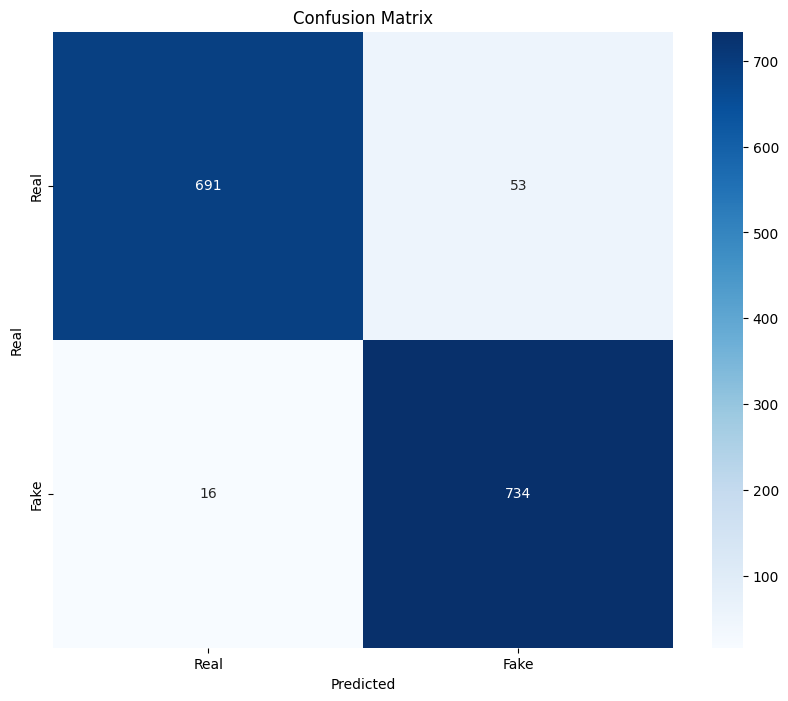

test_accuracy,▁
test_f1_score,▁
test_accuracy,0.95382
test_f1_score,0.95378


In [19]:
# Final plots
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Real')

if GRID_SEARCH:
    plt.title(f'Confusion Matrix - Best hyperparameters\nBS:{best_result["batch_size"]}, LR:{best_result["learning_rate"]}, E:{best_result["num_epochs"]}')
else:
    plt.title(f'Confusion Matrix')  
    
    
wandb.log({"final_confusion_matrix": wandb.Image(plt)})
plt.show()

wandb.finish()

source_dir = "/kaggle/working/CV_project/models"
output_zip = "/kaggle/working/models.zip"

# 💥Adversarial Attacks  

## 🔭Overview

In [ ]:
os.makedirs('CV_project/adversarial_results', exist_ok=True)
if ADV_ATTACK_TYPE == 'All':
    results = run_adversarial_evaluation(model)

## ⚔️FGSM

In [41]:
if ADV_ATTACK_TYPE == 'FGSM':
    attack = AdversarialAttacks(model, DEVICE)
    
    # HYPERPARAMETERS
    eps = 0.01
    #################
    
    print(f"{ADV_ATTACK_TYPE} - eps:{eps}")

    # Performance evaluation
    # config = resolve_data_config({}, model=model)
    # transform = create_transform(**config)
    # test_dataset = datasets.ImageFolder(DATASET_PATHS['test'], transform=transform)
    # test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True, num_workers=2)
    
    fgsm_results = attack.evaluate_robustness(test_loader, 'fgsm', epsilon=eps)

    # Visualization of the attack
    # data_iter = iter(test_loader)   # Get a sample from test set
    # sample_data, sample_target = next(data_iter)
    # sample_data, sample_target = sample_data.to(DEVICE), sample_target.to(DEVICE)
    # attack.visualize_attack(sample_data, sample_target, 'fgsm', epsilon=0.01)

FGSM - eps:0.01

FGSM Attack Results (epsilon=0.01):
Clean Accuracy: 95.38%
Adversarial Accuracy: 33.13%
Attack Success Rate: 62.85%
Average L2 Distance: 302.2442
Average L∞ Distance: 2.0152
Average Confidence Drop: 0.0185


## ⚔️PGD

In [45]:
if ADV_ATTACK_TYPE == 'PGD':
    attack = AdversarialAttacks(model, DEVICE)
    
    # HYPERPARAMETERS
    eps = 0.01
    a = 0.025   # Rule of thumb: eps/4
    n_iter = 10
    #################
    
    print(f"{ADV_ATTACK_TYPE} - eps:{eps}, alpha:{a}, num_iter:{n_iter}")

    # Performance evaluation
    pgd_results = attack.evaluate_robustness(test_loader, 'pgd', epsilon=eps, alpha=a, num_iter=n_iter)

PGD - eps:0.01, alpha:0.025, num_iter:10

PGD Attack Results (epsilon=0.01):
Clean Accuracy: 95.38%
Adversarial Accuracy: 15.66%
Attack Success Rate: 80.19%
Average L2 Distance: 302.2442
Average L∞ Distance: 2.0152
Average Confidence Drop: 0.0149


## ⚔️MI-FGSM

In [47]:
if ADV_ATTACK_TYPE == 'MI-FGSM':
    attack = AdversarialAttacks(model, DEVICE)
    
    # HYPERPARAMETERS
    eps = 0.01
    a = 0.025   # Rule of thumb: eps/4
    n_iter = 10
    decay = 1.0
    #################
    
    print(f"{ADV_ATTACK_TYPE} - eps:{eps}, alpha:{a}, num_iter:{n_iter}, decay:{decay}")

    # Performance evaluation
    mifgsm_results = attack.evaluate_robustness(test_loader, 'mi-fgsm', epsilon=eps, alpha=a, num_iter=n_iter, decay=decay)
    

MI-FGSM - eps:0.01, alpha:0.025, num_iter:10, decay:1.0

MI-FGSM Attack Results (epsilon=0.01):
Clean Accuracy: 95.38%
Adversarial Accuracy: 4.02%
Attack Success Rate: 91.63%
Average L2 Distance: 302.2442
Average L∞ Distance: 2.0152
Average Confidence Drop: -0.0206
